# Task 3.2: Failure Mode Analysis
**Paper**: *Ensemble of Exemplar-SVMs for Object Detection and Beyond* — Malisiewicz, Gupta & Efros (ICCV 2011)

---

## Failure Scenario Description

We construct a scenario where the Exemplar-SVM method fails noticeably by generating a dataset with **heavily overlapping classes** (very low class separation and added label noise).

**Why we expect the method to struggle**: This failure scenario is rooted in **Assumption 1 from Task 1.2**: each exemplar must be visually distinctive enough to define a meaningful decision boundary when trained as the sole positive against many negatives. When classes overlap heavily, individual positive exemplars sit in regions of feature space that are densely populated by negatives. A linear SVM trained on one such exemplar cannot find a hyperplane that separates it — the exemplar looks identical to the negatives surrounding it. In the original paper, this corresponds to detecting objects that are visually indistinguishable from background clutter.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.decomposition import PCA

# ===== RANDOM SEED =====
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ===== HYPERPARAMETERS =====
C_POSITIVE = 0.5
C_NEGATIVE = 0.01
N_MINING_ROUNDS = 3
N_INITIAL_NEGATIVES = 50
ENSEMBLE_THRESHOLD = 0.4


# ===== Helper functions (identical to Task 2.2) =====
def train_esvm_with_mining(exemplar, X_neg, C_pos=0.5, C_neg=0.01,
                            n_initial=50, n_rounds=3, rs=42):
    rng = np.random.RandomState(rs)
    idx = rng.choice(len(X_neg), size=min(n_initial, len(X_neg)), replace=False)
    active = X_neg[idx]
    for r in range(n_rounds):
        X_s = np.vstack([exemplar.reshape(1,-1), active])
        y_s = np.array([1]+[-1]*len(active))
        sw = np.ones(len(y_s)); sw[0] = C_pos/C_neg
        svm = LinearSVC(C=C_neg, loss='hinge', max_iter=10000, random_state=rs, dual=True)
        svm.fit(X_s, y_s, sample_weight=sw)
        sc = svm.decision_function(X_neg)
        hard = X_neg[sc > -1.0]
        if len(hard)==0: break
        active = np.unique(np.vstack([active, hard]), axis=0)
    return svm


def calibrate_platt(svm, X_val, y_val):
    raw = svm.decision_function(X_val).reshape(-1,1)
    lr = LogisticRegression(C=1.0, random_state=RANDOM_SEED)
    lr.fit(raw, y_val)
    return lr


def get_cal_scores(svm, cal, X):
    return cal.predict_proba(svm.decision_function(X).reshape(-1,1))[:,1]


def predict_calibrated(svms, cals, X, thr=0.4):
    scores = np.zeros((X.shape[0], len(svms)))
    for j,(svm,cal) in enumerate(zip(svms,cals)):
        scores[:,j] = get_cal_scores(svm, cal, X)
    mean_s = np.mean(scores, axis=1)
    return (mean_s >= thr).astype(int), mean_s


def run_full_pipeline(X_train, y_train, X_test, y_test):
    """Run the complete Exemplar-SVM pipeline."""
    pos_idx = np.where(y_train == 1)[0]
    neg_idx = np.where(y_train == 0)[0]
    X_pos, X_neg = X_train[pos_idx], X_train[neg_idx]
    
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train, test_size=0.3, random_state=RANDOM_SEED, stratify=y_train
    )
    
    svms = [train_esvm_with_mining(ex, X_neg, C_POSITIVE, C_NEGATIVE,
             N_INITIAL_NEGATIVES, N_MINING_ROUNDS, RANDOM_SEED+i)
            for i,ex in enumerate(X_pos)]
    
    cals = [calibrate_platt(svm, X_val, y_val) for svm in svms]
    y_pred, scores = predict_calibrated(svms, cals, X_test, ENSEMBLE_THRESHOLD)
    
    return {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1': f1_score(y_test, y_pred, zero_division=0)
    }, y_pred


print("Setup complete.")

Setup complete.


## Experiment: Well-Separated vs. Overlapping Classes

In [2]:
# ===== Run on WELL-SEPARATED data (same as Task 2.2) =====
X_good, y_good = make_classification(
    n_samples=500, n_features=10, n_informative=10, n_redundant=0,
    n_classes=2, class_sep=1.5, random_state=RANDOM_SEED
)
X_tr_g, X_te_g, y_tr_g, y_te_g = train_test_split(
    X_good, y_good, test_size=0.3, random_state=RANDOM_SEED, stratify=y_good
)
sc_g = StandardScaler()
X_tr_g = sc_g.fit_transform(X_tr_g)
X_te_g = sc_g.transform(X_te_g)

print("Running on well-separated data (class_sep=1.5)...")
good_m, y_pred_good = run_full_pipeline(X_tr_g, y_tr_g, X_te_g, y_te_g)
print("Well-separated:", {k: f'{v:.4f}' for k,v in good_m.items()})


# ===== Run on OVERLAPPING data (failure scenario) =====
X_bad, y_bad = make_classification(
    n_samples=500, n_features=10, n_informative=10, n_redundant=0,
    n_classes=2, class_sep=0.2, flip_y=0.1,  # very low separation + 10% label noise
    random_state=RANDOM_SEED
)
X_tr_b, X_te_b, y_tr_b, y_te_b = train_test_split(
    X_bad, y_bad, test_size=0.3, random_state=RANDOM_SEED, stratify=y_bad
)
sc_b = StandardScaler()
X_tr_b = sc_b.fit_transform(X_tr_b)
X_te_b = sc_b.transform(X_te_b)

print("\nRunning on overlapping data (class_sep=0.2, flip_y=0.1)...")
bad_m, y_pred_bad = run_full_pipeline(X_tr_b, y_tr_b, X_te_b, y_te_b)
print("Overlapping:", {k: f'{v:.4f}' for k,v in bad_m.items()})

Running on well-separated data (class_sep=1.5)...


Well-separated: {'Accuracy': '0.8867', 'Precision': '0.8372', 'Recall': '0.9600', 'F1': '0.8944'}

Running on overlapping data (class_sep=0.2, flip_y=0.1)...


Overlapping: {'Accuracy': '0.5067', 'Precision': '0.5067', 'Recall': '1.0000', 'F1': '0.6726'}


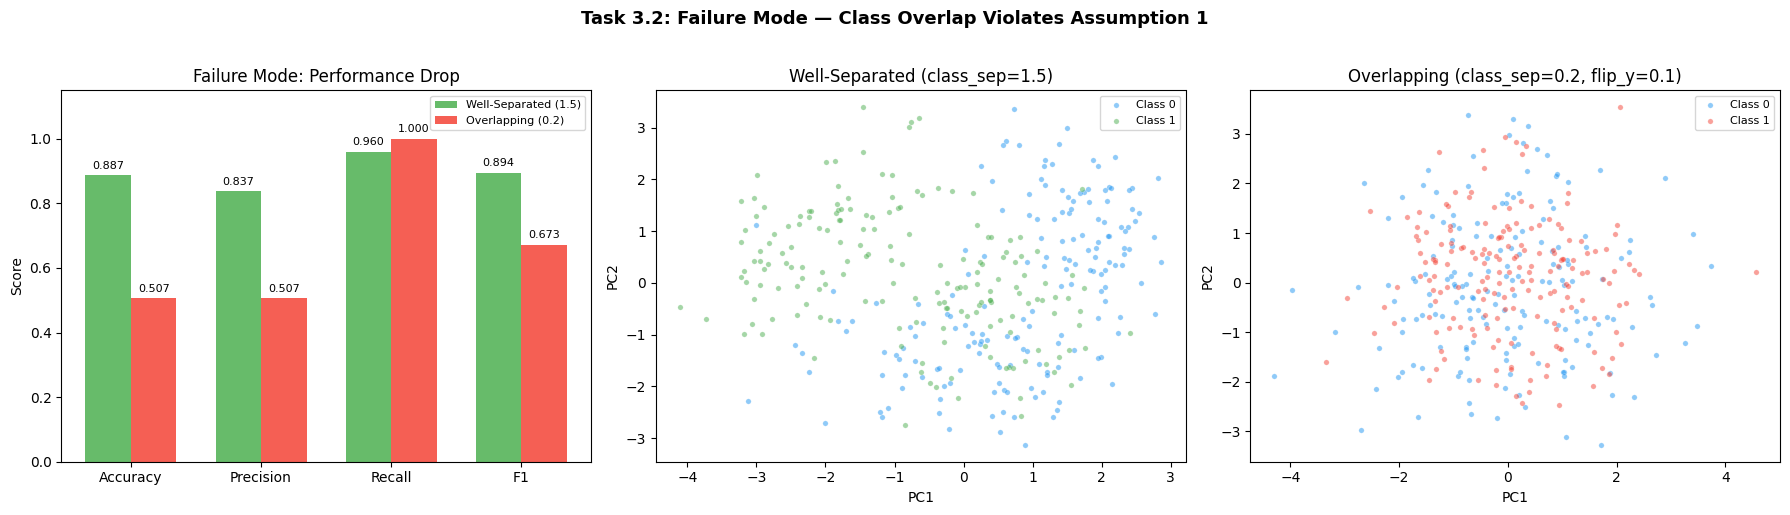

Saved: results/task_3_2_failure_mode.png


In [3]:
os.makedirs('results', exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: Metric comparison bar chart ---
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1']
good_vals = [good_m[m] for m in metrics_names]
bad_vals = [bad_m[m] for m in metrics_names]
x = np.arange(len(metrics_names))
width = 0.35

b1 = axes[0].bar(x - width/2, good_vals, width, label='Well-Separated (1.5)',
                  color='#4CAF50', alpha=0.85)
b2 = axes[0].bar(x + width/2, bad_vals, width, label='Overlapping (0.2)',
                  color='#F44336', alpha=0.85)
axes[0].set_ylabel('Score')
axes[0].set_title('Failure Mode: Performance Drop')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_names)
axes[0].legend(fontsize=8)
axes[0].set_ylim(0, 1.15)
for b in b1:
    axes[0].text(b.get_x()+b.get_width()/2., b.get_height()+0.02,
                 f'{b.get_height():.3f}', ha='center', fontsize=8)
for b in b2:
    axes[0].text(b.get_x()+b.get_width()/2., b.get_height()+0.02,
                 f'{b.get_height():.3f}', ha='center', fontsize=8)

# --- Plot 2: PCA of well-separated data ---
pca_g = PCA(n_components=2, random_state=RANDOM_SEED)
X_g_2d = pca_g.fit_transform(X_tr_g)
for cls, color, label in [(0, '#2196F3', 'Class 0'), (1, '#4CAF50', 'Class 1')]:
    mask = y_tr_g == cls
    axes[1].scatter(X_g_2d[mask,0], X_g_2d[mask,1], c=color,
                    alpha=0.5, s=15, label=label, edgecolors='white', linewidths=0.3)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('Well-Separated (class_sep=1.5)')
axes[1].legend(fontsize=8)

# --- Plot 3: PCA of overlapping data ---
pca_b = PCA(n_components=2, random_state=RANDOM_SEED)
X_b_2d = pca_b.fit_transform(X_tr_b)
for cls, color, label in [(0, '#2196F3', 'Class 0'), (1, '#F44336', 'Class 1')]:
    mask = y_tr_b == cls
    axes[2].scatter(X_b_2d[mask,0], X_b_2d[mask,1], c=color,
                    alpha=0.5, s=15, label=label, edgecolors='white', linewidths=0.3)
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')
axes[2].set_title('Overlapping (class_sep=0.2, flip_y=0.1)')
axes[2].legend(fontsize=8)

plt.suptitle('Task 3.2: Failure Mode — Class Overlap Violates Assumption 1', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig('results/task_3_2_failure_mode.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/task_3_2_failure_mode.png")

## Why the Method Fails

The Exemplar-SVM method degrades dramatically on the overlapping dataset. The PCA plots above show the root cause clearly: in the well-separated dataset, the two classes occupy distinct regions of feature space, so each positive exemplar can learn a meaningful hyperplane separating itself from the negatives. In the overlapping dataset, the classes are completely intermixed — positive and negative points are indistinguishable in the feature space.

This failure is directly caused by **violating Assumption 1 from Task 1.2**: each exemplar must be sufficiently distinctive to separate itself from the negative class. When `class_sep=0.2` with 10% label noise, individual positive exemplars sit in the middle of a cloud of negatives. A linear SVM trained with this single positive cannot find a meaningful decision boundary — any hyperplane will misclassify roughly half the negatives, and the positive exemplar offers no discriminative advantage. As each individual Exemplar-SVM becomes effectively random, the calibration step (Section 3.1) cannot recover accuracy because the underlying classifiers contain no useful signal.

The failure also reveals a deeper limitation of the per-exemplar approach. When exemplars are not distinctive, training separate classifiers per exemplar wastes the information present in the aggregate positive class. A standard SVM that pools all positives together would have more statistical power in overlapping regions, because the combined positive set reveals the class boundary more robustly than any single point.

---

## Suggested Modification

To address this failure, one could **group similar exemplars into clusters and train one SVM per cluster** with multiple positives, creating a semi-parametric approach similar to Felzenszwalb et al.'s deformable part models [9]. This would provide more robust positive-class estimation in overlapping regions while retaining finer-grained associations than a single monolithic classifier.